# Ground Metric Deformation

This notebook generates `fig:metric-learning-cost-deformation`.  We keep the empirical measures fixed and change only the Mahalanobis ground cost
$$
    c_A(x,y)=(x-y)^\top A(x-y).
$$
The clouds are intentionally close, so changing $A$ visibly changes which red and blue atoms are coupled.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from matplotlib.patches import Ellipse
import ot

NAME = "metric-learning-cost-deformation"
out = figure_dir(NAME)
rng = np.random.default_rng(171)

In [2]:
def rot(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

n = 32
x = np.vstack([
    rng.normal(size=(16, 2)) @ np.diag([0.20, 0.095]) + np.array([-0.48, -0.16]),
    rng.normal(size=(16, 2)) @ np.diag([0.19, 0.105]) + np.array([-0.02, 0.35]),
])
y = np.vstack([
    rng.normal(size=(16, 2)) @ np.diag([0.19, 0.105]) + np.array([0.10, -0.38]),
    rng.normal(size=(16, 2)) @ np.diag([0.20, 0.105]) + np.array([0.56, 0.22]),
])
a = b = np.ones(n) / n

R = rot(np.deg2rad(32))
metrics = {
    "euclidean": np.eye(2),
    "moderate": R @ np.diag([0.34, 2.65]) @ R.T,
    "strong": R @ np.diag([0.025, 15.00]) @ R.T,
}

def cost_matrix(A):
    d = x[:, None, :] - y[None, :, :]
    return np.einsum("...i,ij,...j->...", d, A, d)

plans = {key: ot.emd(a, b, cost_matrix(A)) for key, A in metrics.items()}

In [3]:
def metric_ellipse(A, scale=0.15):
    w, V = np.linalg.eigh(A)
    order = np.argsort(w)
    w, V = w[order], V[:, order]
    angle = np.degrees(np.arctan2(V[1, 0], V[0, 0]))
    return scale / np.sqrt(w[0]), scale / np.sqrt(w[1]), angle


def ellipse_boundary(center, width, height, angle, n=96):
    th = np.linspace(0, 2*np.pi, n, endpoint=False)
    pts = np.column_stack([0.5 * width * np.cos(th), 0.5 * height * np.sin(th)])
    R = rot(np.deg2rad(angle))
    return np.asarray(center) + pts @ R.T


def draw_metric_plan(P, A, filename):
    fig, ax = plt.subplots(figsize=(2.22, 2.05))
    pairs = [(i, j, float(P[i, j])) for i in range(n) for j in range(n) if P[i, j] > 1e-10]
    draw_transport_segments(ax, x, y, pairs, color=VIOLET, min_width=0.18, max_width=0.88, alpha_scale=0.48, zorder=1)
    draw_point_clouds(ax, x, y, base_size=DIRAC_MARKER_SIZE * 0.68)
    width, height, angle = metric_ellipse(A)
    ax.add_patch(Ellipse([0.60, -0.56], width, height, angle=angle, fill=False, edgecolor=GRAY, lw=0.82, alpha=0.86))
    ellipse_pts = ellipse_boundary([0.60, -0.56], width, height, angle)
    pts = np.vstack([x, y, ellipse_pts])
    ax.set_xlim(pts[:, 0].min() - 0.20, pts[:, 0].max() + 0.20)
    ax.set_ylim(pts[:, 1].min() - 0.20, pts[:, 1].max() + 0.20)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.040)
    plt.close(fig)

for key, A in metrics.items():
    draw_metric_plan(plans[key], A, f"{key}.pdf")


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


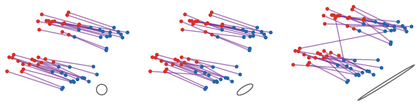

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/metric-learning-cost-deformation.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/metric-learning-cost-deformation.png")
display(Image(filename=str(_thumb)))
